In [1]:
import numpy as np
import pandas as pd
from gensim.models import Word2Vec
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Dropout 

In [2]:
true_data = pd.read_csv("News _dataset/True.csv")
fake_data = pd.read_csv("News _dataset/Fake.csv") 
true_data['label'] = 1
fake_data['label'] = 0 
data = pd.concat([true_data, fake_data], axis=0).reset_index(drop=True) 

In [3]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

In [4]:
nltk.download('stopwords')
nltk.download('punkt_tab')
stop_words = set(stopwords.words('english'))
nltk.download('wordnet') 

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [5]:
lemmatizer = WordNetLemmatizer() 

In [6]:
def preprocess_text(text):
    text = re.sub(r'[^\w\s]', '', text)  # Loại bỏ dấu câu
    text = re.sub(r'\d+', '', text)      # Loại bỏ số
    text = text.lower()                  # Chuyển về chữ thường
    words = word_tokenize(text)          # Tokenize
    words = [word for word in words if word not in stop_words]  # Loại bỏ stop words
    words = [lemmatizer.lemmatize(word) for word in words]  # Lematize các từ
    return words 

In [7]:
data['processed_text'] = data['text'].apply(preprocess_text) 

In [8]:
from gensim.models import Word2Vec
sentences = data['processed_text']
word2vec_model = Word2Vec(sentences, vector_size=100, window=5, min_count=1, workers=4) 

In [9]:
# Tạo embedding matrix
vocab_size = len(word2vec_model.wv)
embedding_dim = 100
embedding_matrix = np.zeros((vocab_size + 1, embedding_dim))
word_index = {word: idx + 1 for idx, word in enumerate(word2vec_model.wv.index_to_key)}

for word, idx in word_index.items():
    embedding_matrix[idx] = word2vec_model.wv[word] 

In [10]:
# 4. Tokenization và padding
tokenizer = Tokenizer(num_words=vocab_size)
tokenizer.fit_on_texts(data['text'])
sequences = tokenizer.texts_to_sequences(data['text'])
max_length = 100  # Độ dài cố định
X = pad_sequences(sequences, maxlen=max_length, padding='post')

In [11]:
# Nhãn
y = data['label'].values 

In [12]:
# 5. Chia tập dữ liệu
from sklearn.model_selection import train_test_split  
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) 

In [13]:
# 6. Xây dựng mô hình RNN
model = Sequential([
    Embedding(input_dim=vocab_size + 1, 
              output_dim=embedding_dim, 
              weights=[embedding_matrix], 
              input_length=max_length, 
              trainable=False),
    SimpleRNN(128, activation='tanh'),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')  # Đầu ra nhị phân
]) 

c:\Users\Admin\OneDrive\Tài liệu\Fake_news_detection_project\venv\Lib\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [14]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary() 

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │    20,351,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,351,500 (77.63 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 20,351,500 (77.63 MB)

In [15]:
# 7. Huấn luyện mô hình
history = model.fit(X_train, y_train, 
                    validation_data=(X_test, y_test), 
                    epochs=10, 
                    batch_size=32) 

Epoch 1/10
1123/1123 ━━━━━━━━━━━━━━━━━━━━ 39s 29ms/step - accuracy: 0.7577 - loss: 0.4764 - val_accuracy: 0.8570 - val_loss: 0.3198
Epoch 2/10
1123/1123 ━━━━━━━━━━━━━━━━━━━━ 32s 29ms/step - accuracy: 0.8439 - loss: 0.3374 - val_accuracy: 0.7242 - val_loss: 0.4665
Epoch 3/10
1123/1123 ━━━━━━━━━━━━━━━━━━━━ 33s 29ms/step - accuracy: 0.8121 - loss: 0.3771 - val_accuracy: 0.8602 - val_loss: 0.2939
Epoch 4/10
1123/1123 ━━━━━━━━━━━━━━━━━━━━ 32s 28ms/step - accuracy: 0.8656 - loss: 0.3050 - val_accuracy: 0.8608 - val_loss: 0.3316
Epoch 5/10
1123/1123 ━━━━━━━━━━━━━━━━━━━━ 31s 27ms/step - accuracy: 0.8611 - loss: 0.3328 - val_accuracy: 0.8470 - val_loss: 0.3247
Epoch 6/10
1123/1123 ━━━━━━━━━━━━━━━━━━━━ 30s 27ms/step - accuracy: 0.8592 - loss: 0.3194 - val_accuracy: 0.7164 - val_loss: 1.0501
Epoch 7/10
1123/1123 ━━━━━━━━━━━━━━━━━━━━ 29s 26ms/step - accuracy: 0.8195 - loss: 0.3924 - val_accuracy: 0.8594 - val_loss: 0.3078
Epoch 8/10
1123/1123 ━━━━━━━━━━━━━━━━━━━━ 35s 31ms/step - accuracy: 0.8631 -

In [16]:
# 8. Đánh giá mô hình
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy:.2f}")

281/281 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.8679 - loss: 0.2867
Test Accuracy: 0.87


In [17]:
# 9. Hàm tiền xử lý văn bản
def preprocess_and_tokenize(text):
    # Tiền xử lý
    text = preprocess_text(text)
    # Tokenize
    sequence = tokenizer.texts_to_sequences([text])
    # Padding
    padded_sequence = pad_sequences(sequence, maxlen=max_length, padding='post')
    return padded_sequence

In [18]:
# 10. Hàm kiểm tra tin giả
def check_fake_news(text):
    # Chuẩn hóa và chuyển đổi sang dạng mô hình chấp nhận
    processed_text = preprocess_and_tokenize(text)
    # Dự đoán
    prediction = model.predict(processed_text)[0][0]
    # Trả kết quả
    return "True News" if prediction >= 0.5 else "Fake News" 

In [19]:
 # 11. Kiểm tra thử với một đoạn văn bản
new_text = "sad"
result = check_fake_news(new_text)
print(f"Doan van ban la: {result}") 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 256ms/step
Doan van ban la: True News


In [20]:
model.save('RNN_model_using_Word2Vec.h5')

In [21]:
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score
# Dự đoán nhãn của tập kiểm tra
y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5).astype(int).flatten()  # Chuyển kết quả dự đoán thành nhãn 0 hoặc 1

# Tính toán các chỉ số đánh giá
print("Classification Report:")
print(classification_report(y_test, y_pred))

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")

281/281 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step
Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.75      0.86      4650
           1       0.79      0.99      0.88      4330

    accuracy                           0.87      8980
   macro avg       0.89      0.87      0.87      8980
weighted avg       0.89      0.87      0.87      8980

Accuracy: 0.87
Precision: 0.79
Recall: 0.99
F1 Score: 0.88


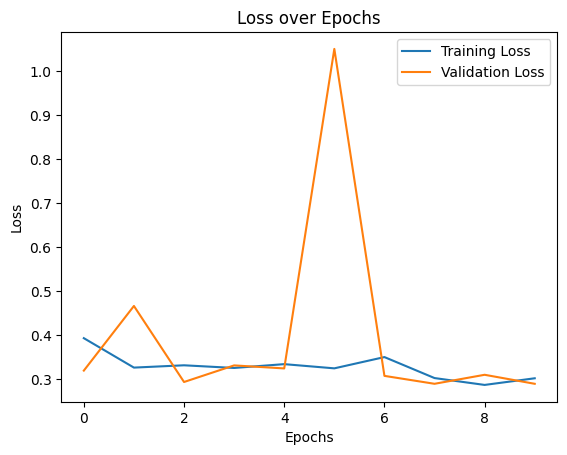

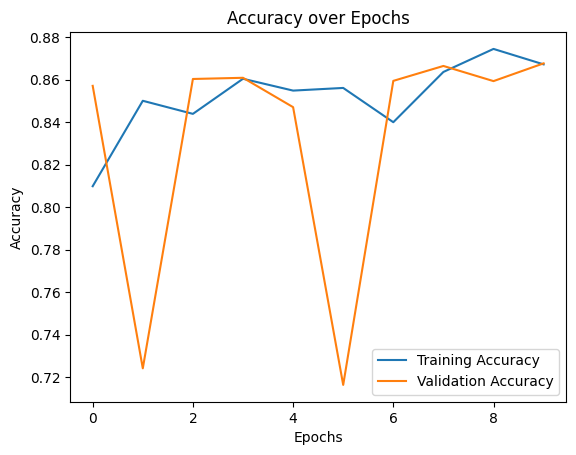

In [22]:
import matplotlib.pyplot as plt
# Vẽ biểu đồ Loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Vẽ biểu đồ Accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()